In [1]:
import numpy as np
from scipy.special import i0, i1, i0e
from scipy.stats import norm, rayleigh, rice
import matplotlib.pyplot as plt
from statistics import NormalDist
import seaborn as sns
import pandas as pd
import scipy.special as sp
import scipy.optimize as opt
from scipy import stats

import matplotlib.colors as mcolors

In [2]:
def pdf_rice(quantiles, noncentrality, scale, l=1):
    """
    Computes the PDF of the Rice distribution at given quantiles,
    with parameters noncentrality (noncentrality parameter) and scale (scale parameter).
    Adapted from https://rdrr.io/cran/lmomco/src/R/pdfrice.R , book:
    https://www.researchgate.net/profile/William-Asquith/publication/308775618_Distributional_analysis_with_L-moment_statistics_using_the_R_environment_for_statistical_computing/links/57ef281408ae91deaa510cb5/Distributional-analysis-with-L-moment-statistics-using-the-R-environment-for-statistical-computing.pdf
    
    Parameters:
    - quantiles: array-like, quantiles at which to evaluate the PDF.
    - noncentrality: float, noncentrality parameter (nu).
    - scale: float, scale parameter (alpha).
    
    Returns:
    - pdf_values: array-like, PDF values at quantiles.
    """
    quantiles = np.asarray(quantiles)
    # Handle the special case when noncentrality == 0 (Rayleigh distribution)
    if noncentrality == 0:
        return rayleigh.pdf(quantiles, scale=scale)
    
    snr = noncentrality / scale  # Signal-to-noise ratio
    print("snr is", snr)
    
    # For large snr (>52), approximate using the normal distribution
    if snr > 52:
        print("large snr, normal distribution")
        mean = noncentrality / l     # Mean of the normal approximation
        variance = scale**2 / l**2       # Variance of the normal approximation  # as snr --> infinity: 2 * scale^2 + noncentrality^2 - scale^2 * snr^1
        return norm.pdf(quantiles, loc=mean, scale=np.sqrt(variance)), mean, variance
    
    # For moderate snr (24 < snr <= 52), use normal approximation with Laguerre polynomials
    elif snr > 24:
        print("moderate snr, normal distribution with Laguerre")
        # Compute the parameter for the Laguerre half 
        x_param = - noncentrality**2 / (2 * scale**2)
        x2 = x_param / 2   
        
        laguerre_05 = np.exp(x2) * ((1 - x_param) * i0(-x2) - x_param * i1(-x2)) # L_{1/2}(x) = \exp^{x/2}\times[(1-x)I_0(-x/2) - xI_1(-x/2)]
        
        # Compute mean and variance for the normal approximation
        mean = (scale * np.sqrt(np.pi / 2) * laguerre_05) / l
        variance = (2 * scale**2 + noncentrality**2 - scale**2 * (np.pi / 2) * laguerre_05**2) / l**2
        
        # Return the normal PDF with the computed mean and variance
        return norm.pdf(quantiles, loc=mean, scale=np.sqrt(variance)), mean, variance
    
    else:
        # For small snr (<=24), compute the Rice PDF directly
        print("very small snr, exact computation")

        # Commented out code follows definition from links above, but has overflow in exponential for large V and x
        # B = V / A**2
        # tmp = x / A**2 - np.exp(x**2 + V**2) / (2 * A**2)
        # toI0 = x * B
        # Bo = i0e(toI0)
        # f = tmp + np.log(Bo) + toI0
        # f[~np.isfinite(f)] = 0

        b_param = noncentrality / scale**2
        
        # Compute the logarithm of the tmp term
        log_tmp = np.log(quantiles / scale**2) - (quantiles**2 + noncentrality**2) / (2 * scale**2)
        
        to_i0 = quantiles * b_param
        
        # Compute log(I0(z)) using i0e
        log_bessel = np.log(i0e(to_i0)) + to_i0
        
        log_pdf = log_tmp + log_bessel
        pdf_values = np.exp(log_pdf)

        mean, variance = rice.stats(noncentrality/scale, 0, scale, moments='mv')

        
        return pdf_values, mean, variance
    

def compute_inverse_moments(mu, sigma, a):
    """
    Computes approximations for E(1/X) and Var(1/X) for a truncated normal variable X,
    using the Dawson's integral approximations as in Richard L. Hall's paper.
    
    Parameters:
        mu    : float, the mean parameter of the underlying normal (mu > 0)
        sigma : float, the standard deviation of the underlying normal
        a     : float, the truncation lower bound (a > 0)
    
    Returns:
        E_inv : float, approximation for E(1/X)
        var_inv: float, approximation for Var(1/X)
    """
    sigma1 = sigma / mu

    # Check the validity conditions for the approximation:
    if sigma1 >= 0.2:
        print("Warning: sigma/mu is not << 1/5. The approximation may be inaccurate.")
    # Check condition: sigma1^2 << a/mu <= 1/25.
    # Here we check if a/mu is at least 10 times sigma1^2 and at most 1/25.
    ratio = a / mu
    if not (sigma1**2 <= ratio <= 1/25):
        print("Warning: The condition sigma1^2 <= a/mu <= 1/25 = 0.04 is not clearly satisfied.")
        print(f"  (a/mu = {ratio:.5f}, sigma1^2 = {sigma1**2:.5f})")
    
    # Compute Dawson's integral using scipy.special.dawsn.
    # Dawson's integral is defined as: D(x) = e^(-x^2) * ∫_0^x e^(t^2) dt.
    arg = 1 / (np.sqrt(2) * sigma1)
    D_value = sp.dawsn(arg)
    
    # Compute I(sigma1) and J(sigma1) as given by Hall.
    I_val = (np.sqrt(2) / sigma1) * D_value
    J_val = (I_val - 1) / (sigma1 ** 2)
    
    # According to the theorem:
    #   mu * E(1/X)   = I(sigma1) + e1,  with |e1| very small.
    #   mu^2 * E(1/X^2) = J(sigma1) + e2.
    # Hence, we approximate:
    E_inv = I_val / mu
    E_inv2 = J_val / (mu ** 2)
    var_inv = (J_val - I_val**2) / (mu ** 2)
    
    return E_inv, var_inv

def find_mean_and_std(data):
    """Helper function to compute the mean and standard deviation of an array."""
    return np.mean(data), np.std(data)

def format_omega(key):
    r"""
    Convert keys like 'w4', 'w6', 'w8', etc. to LaTeX formatted strings,
    e.g. "$\omega = 4$".
    """
    # If key starts with 'w' and has more characters, format accordingly.
    if key.startswith('w') and len(key) > 1:
        return r'$\omega = {}$'.format(key[1:])
    return key

snr is 44.704862055016164
moderate snr, normal distribution with Laguerre


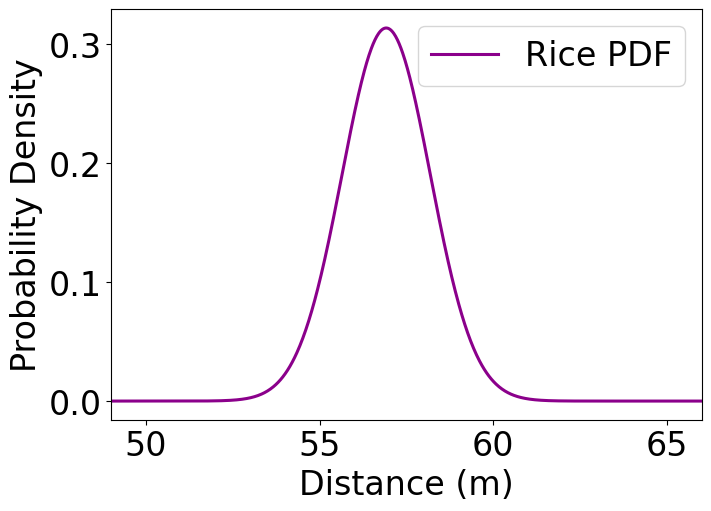

In [3]:
from matplotlib.ticker import MaxNLocator
dist = 56.9  # distance in meters (as in your original code)
a_val = 0.045  # truncation parameter for the inverse moments computation

scale = np.sqrt(2)*0.9
noncentrality = dist
x = np.linspace(49, 66, 1000)
# We ignore the returned PDF values; we only need mean and variance.
pdf_values, mean_rice, var_rice = pdf_rice(x, noncentrality, scale, l=1)

plt.rcParams.update({'font.size': 24})
plt.figure(figsize=(7,5), constrained_layout=True)
plt.plot(x, pdf_values, label="Rice PDF", color="darkmagenta", lw=2.2)
# Get the current axes
ax = plt.gca()

# Limit the number of ticks on x and y axes
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
plt.xlabel('Distance (m)')
plt.ylabel('Probability Density')
plt.legend(loc="upper right")
plt.xlim(49,66)
plt.show()


In [4]:
data_w = {}
for w in ["w4", "w6", "w8"]:
    # Load the time-uncertainty results: [velocities, lag_times]
    t_file = f"output/neg_group_vel_t_100000_{w}.npy"
    t_data = np.load(t_file)
    
    # Load the distance uncertainty data (single array)
    p_file = f"output/neg_group_vel_p_100000_{w}.npy"
    p_data = np.load(p_file)
    
    # Load the combined uncertainty results: [velocities, lag_times]
    pt_file = f"output/neg_group_vel_pt_100000_{w}.npy"
    pt_data = np.load(pt_file)

    lag_file = f"output/true_mean_lag_{w}.npy"
    lag_data = np.load(lag_file)

    heis_std_file = f"output/heisenberg_std_{w}.npy"
    heis_std = np.load(heis_std_file)
    
    data_w[w] = {
        "lagUncertain_heis":           t_data[0],
        "lag_time_lagUncertain_heis":  t_data[1],
        "DisUncertain":                p_data,
        "CombUncertain_heis":          pt_data[0],
        "lag_time_CombUncertain_heis": pt_data[1],
        "picked_lag_times":            lag_data,
        "heisenberg_std":              heis_std,
    }


# Load other global arrays (which do not depend on "w")
freq = np.load("output/freqs.npy")
# For example, if you want to select the first frequency, set:
id_freq = 0
print(freq[id_freq])

3.6


3.600 Hz, $\omega = 4$


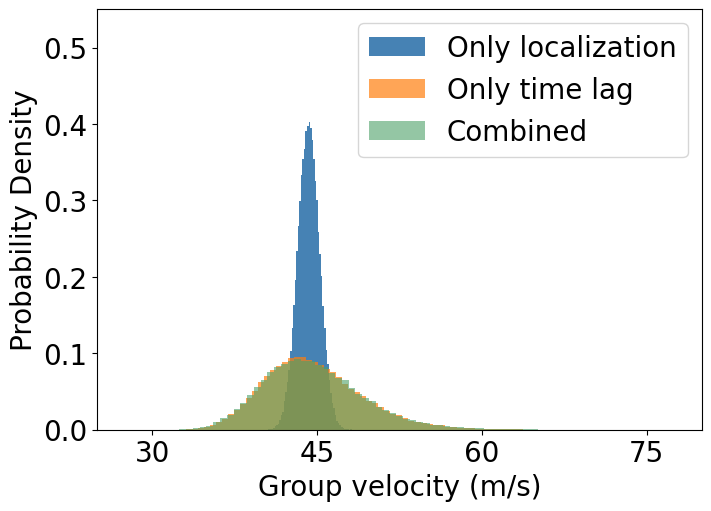

3.600 Hz, $\omega = 6$


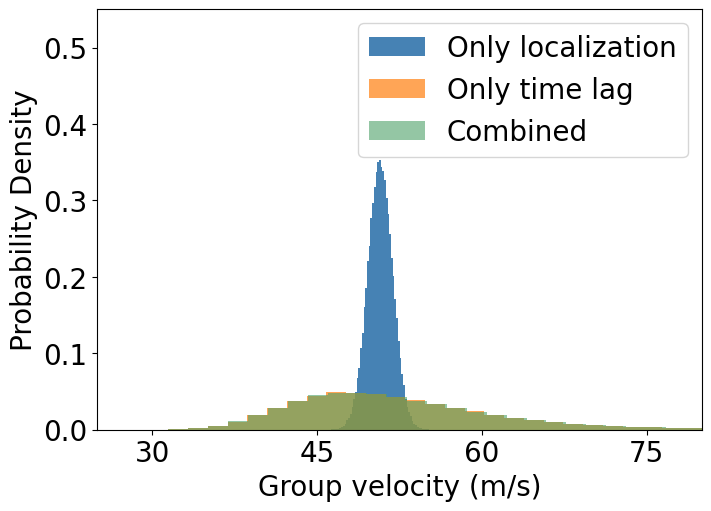

3.600 Hz, $\omega = 8$


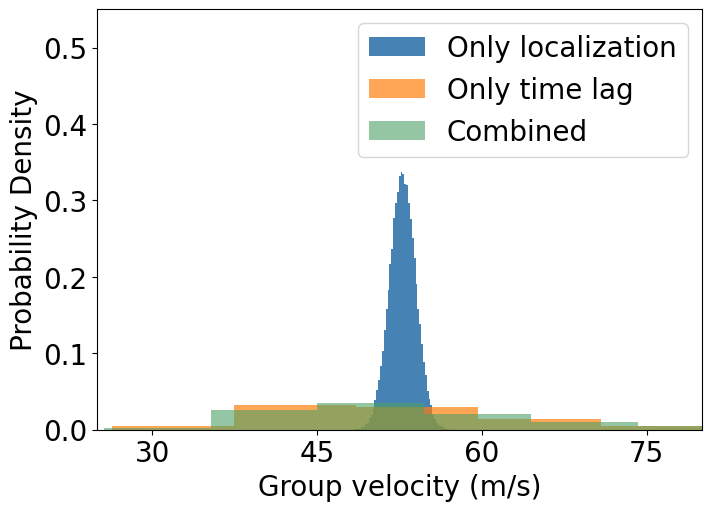

In [5]:
for w, d in data_w.items():
    # Extract one-frequency data from the arrays (all arrays are assumed to have shape [n_samples, n_freqs])
    oneFreq_Dist       = d["DisUncertain"][:, id_freq]
    oneFreq_true_lag = d["picked_lag_times"][id_freq]

    oneFreq_Time_heis  = d["lagUncertain_heis"][:, id_freq]
    oneFreq_Comb_heis  = d["CombUncertain_heis"][:, id_freq]
    oneFreq_lag_only_heis= d["lag_time_lagUncertain_heis"][:, id_freq]
    oneFreq_lag_comb_heis= d["lag_time_CombUncertain_heis"][:, id_freq]

    # Example: Plot velocity histograms (Heisenberg case)
    print(f"{freq[id_freq]:.3f} Hz, {format_omega(w)}")
    plt.rcParams.update({'font.size': 20})
    plt.figure(figsize=(7, 5), constrained_layout=True)
    #plt.title(f"For {freq[id_freq]:.3f} Hz, {format_omega(w)}: Velocity probability density histograms (Heisenberg)")
    plt.hist(oneFreq_Dist, 60, density=True, label="Only localization", color="steelblue")
    plt.hist(oneFreq_Time_heis, 80, density=True, label="Only time lag", color="tab:orange", alpha=0.7)
    plt.hist(oneFreq_Comb_heis, 80, density=True, label="Combined", color="#4DA167", alpha=0.6)
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    plt.xlabel("Group velocity (m/s)")
    plt.ylabel("Probability Density")
    plt.xlim(25, 80)
    plt.ylim(0,0.55)
    plt.legend()   
    plt.show()

    # plt.figure(figsize=(7, 5))
    # plt.title(f"For {freq[id_freq]:.3f} Hz, {format_omega(w)}: Probability density histogram of time-lag samples (Heisenberg)")
    # plt.hist(oneFreq_lag_only_heis,90,density=True,  color="lime")
    # plt.hist(oneFreq_lag_comb_heis,90,density=True,  color="blue", alpha=0.5)
    # plt.xlabel("time-lag (Hz)")
    # plt.ylabel("Probability Density")
    # plt.legend()
    # plt.show()


In [6]:

dist = 56.9
true_lag = oneFreq_true_lag

L = oneFreq_Dist * true_lag
T = oneFreq_lag_only_heis

Tinv      = 1.0 / T                             # reciprocal
mu_L      = L.mean()
mu_Tinv   = Tinv.mean()
var_L     = L.var(ddof=1)                       # sample variance (unbiased)
var_Tinv  = Tinv.var(ddof=1)

# sample covariance between L and T^{-1}
cov_LTinv = np.cov(L, Tinv, ddof=1)[0, 1]

# sample (Pearson) correlation ρ̂ and its two-sided p-value
rho_hat, pval = stats.pearsonr(L, Tinv)

print(f"Sample correlation rho_hat = {rho_hat: .5f}  (p = {pval:.4g})")
print(f"Sample covariance    = {cov_LTinv: .5f}")

# --- textbook expression assuming independence --------------------
var_V_indep = (var_L + mu_L**2) * (var_Tinv + mu_Tinv**2) - (mu_L * mu_Tinv)**2
var_V_delta_indep = mu_Tinv**2 * var_L + mu_L**2 * var_Tinv


# --- first-order delta method (keeps the covariance term) ---------
var_V_delta_full = (
    mu_Tinv**2 * var_L
    + mu_L**2  * var_Tinv
    + 2 * mu_L * mu_Tinv * cov_LTinv
)

rel_error_approx = abs((var_V_indep - var_V_delta_indep) / var_V_indep)
rel_error = abs(var_V_delta_full - var_V_indep) / var_V_delta_full
print(f"Relative error incurred by dropping Cov term = {100*rel_error: .2f}%")
print(f"Relative error incurred by approximating Var[V] = {100*rel_error_approx: .2f}%")

Sample correlation rho_hat =  0.00422  (p = 0.1816)
Sample covariance    =  0.00154
Relative error incurred by dropping Cov term =  0.02%
Relative error incurred by approximating Var[V] =  0.05%


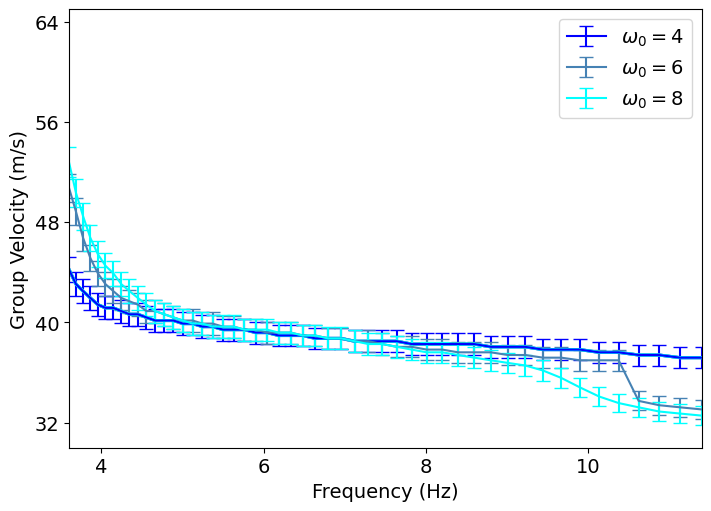

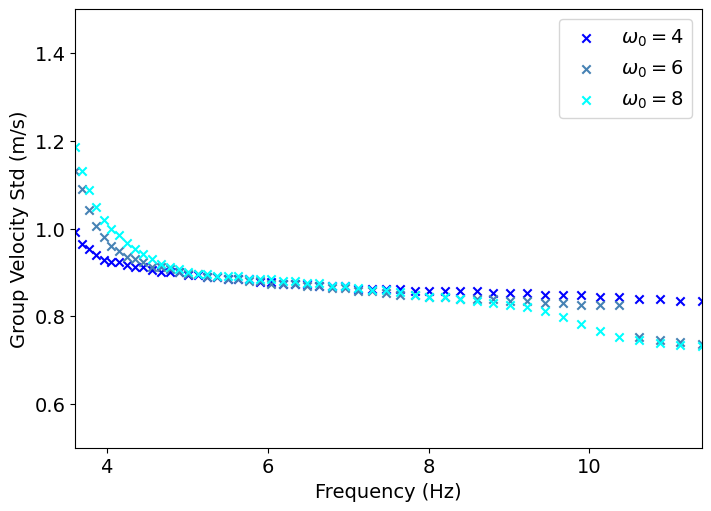

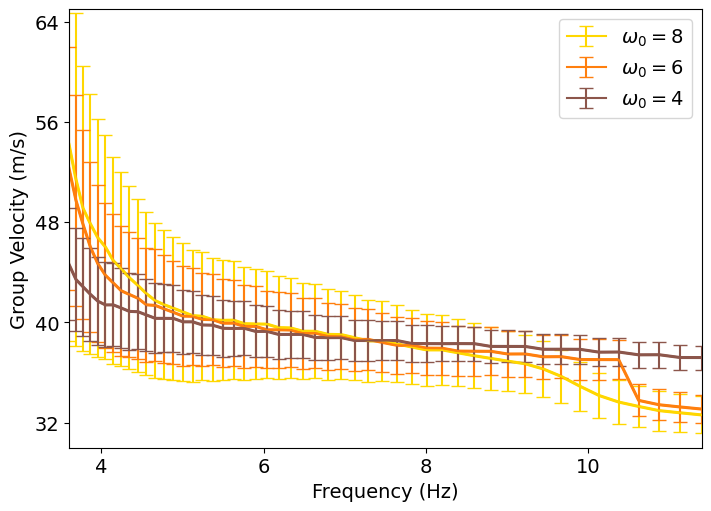

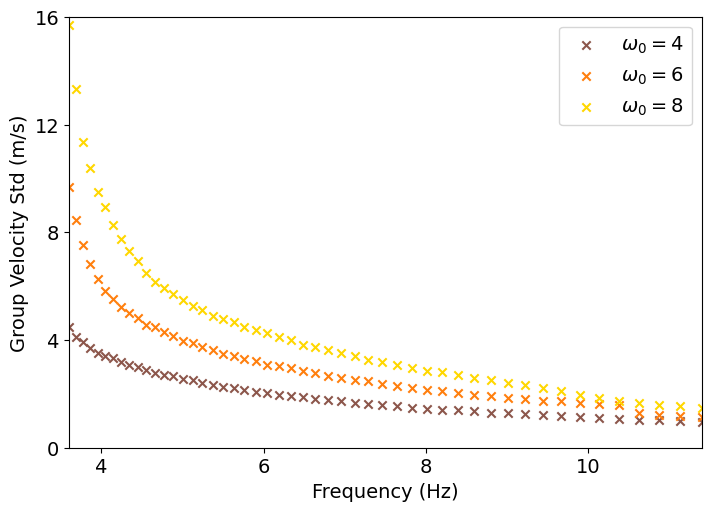

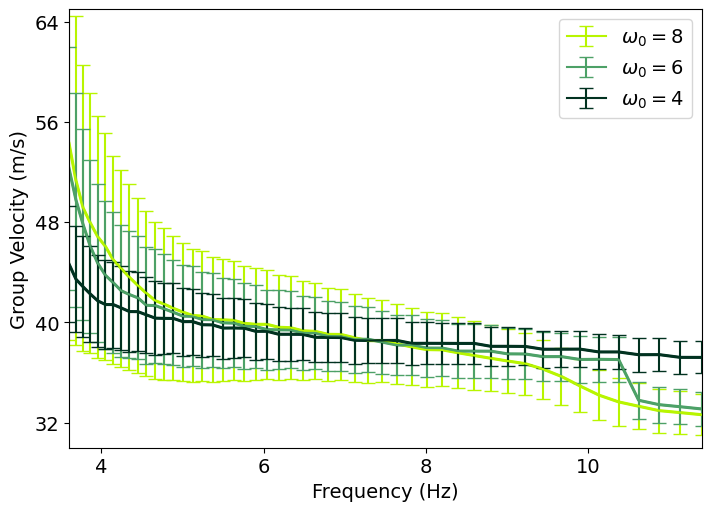

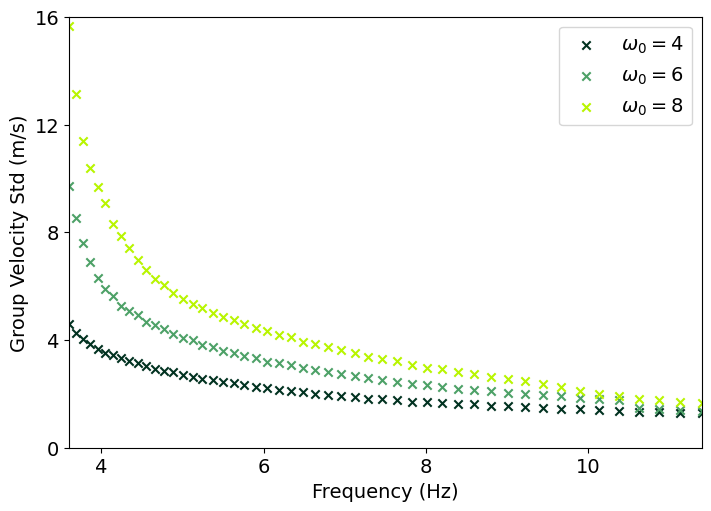

In [7]:
from matplotlib.ticker import MaxNLocator
dispersion_results = {}
fmin, fmax = 3.6, 11.4
for w, d in data_w.items():
    nf = len(freq)
    mean_velocities_dist = np.zeros(nf)
    std_velocities_dist  = np.zeros(nf)
    mean_velocities_time = np.zeros(nf)
    std_velocities_time  = np.zeros(nf)
    mean_velocities_comb = np.zeros(nf)
    std_velocities_comb  = np.zeros(nf)
    
    for i in range(nf):
        vel_time = d["lagUncertain_heis"][:, i]
        vel_dist = d["DisUncertain"][:, i]
        vel_comb = d["CombUncertain_heis"][:, i]
        mean_velocities_dist[i], std_velocities_dist[i] = find_mean_and_std(vel_dist)
        mean_velocities_time[i], std_velocities_time[i] = find_mean_and_std(vel_time)
        mean_velocities_comb[i], std_velocities_comb[i] = find_mean_and_std(vel_comb)
    
    dispersion_results[w] = {
         "mean_dist": mean_velocities_dist,
         "std_dist": std_velocities_dist,
         "mean_time": mean_velocities_time,
         "std_time": std_velocities_time,
         "mean_comb": mean_velocities_comb,
         "std_comb": std_velocities_comb,
    }
    

    # # Limit the number of ticks on x and y axes
    # plt.rcParams.update({'font.size': 14})
    
    # # Plot the dispersion curve for this key
    # plt.figure(figsize=(7, 5))
    # #plt.errorbar(freq, mean_velocities_comb, yerr=std_velocities_comb, fmt='+', color='C0', capsize=5, label="Combined uncertainty (std)")
    # #plt.errorbar(freq, mean_velocities_time, yerr=std_velocities_time, fmt='x', color='green', capsize=5, label="Only time uncertainties (std)")
    # plt.errorbar(freq, mean_velocities_dist, yerr=std_velocities_dist, color='C1',  label="Only distance uncertainty (std)")
    # ax = plt.gca()
    # ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    # ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    # plt.xlabel('Frequency (Hz)')
    # plt.ylabel('Group Velocity (m/s)')
    # #plt.title(f'Group Velocity Dispersion Curve with Uncertainties ({format_omega(w)})')
    # #plt.legend()
    # #plt.xlim(5,9)
    # plt.ylim(25,55)
    # plt.xlim(fmin, fmax)
    # plt.show()

    
##########
# Only POSITION uncertainty
##########

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(7, 5), constrained_layout=True)
# Here we use different colors and labels for each omega value.
plt.errorbar(freq, dispersion_results["w4"]["mean_dist"], yerr=dispersion_results["w4"]["std_dist"],
             color='blue', capsize=5, label=r"$\omega_0 = 4$")
plt.plot(
    freq,
    dispersion_results["w4"]["mean_dist"],
    lw=2.2, 
    color='blue',
)
plt.errorbar(freq, dispersion_results["w6"]["mean_dist"], yerr=dispersion_results["w6"]["std_dist"],
             color='steelblue', capsize=5, label=r"$\omega_0 = 6$")
plt.plot(
    freq,
    dispersion_results["w4"]["mean_dist"],
    lw=2.2, 
    color='steelblue',
)
plt.errorbar(freq, dispersion_results["w8"]["mean_dist"], yerr=dispersion_results["w8"]["std_dist"],
             color='aqua', capsize=5, label=r"$\omega_0 = 8$")
plt.plot(
    freq,
    dispersion_results["w4"]["mean_dist"],
    lw=2.2, 
    color='aqua',
)
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Group Velocity (m/s)')
#plt.title('Group Velocity Dispersion Curve with Time Uncertainty Only')
plt.legend()
plt.ylim(30,65)
plt.xlim(fmin,fmax)
plt.show()   


plt.figure(figsize=(7, 5), constrained_layout=True)
plt.scatter(freq, dispersion_results["w4"]["std_dist"],
             color='blue', marker = 'x', label=r"$\omega_0 = 4$")

plt.scatter(freq, dispersion_results["w6"]["std_dist"],
             color='steelblue', marker = 'x', label=r"$\omega_0 = 6$")

plt.scatter(freq, dispersion_results["w8"]["std_dist"],
             color='aqua', marker = 'x', label=r"$\omega_0 = 8$")
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Group Velocity Std (m/s)')
#plt.title('Group Velocity Dispersion Curve with Time Uncertainty Only')
plt.legend()
plt.ylim(0.5,1.5)
plt.xlim(fmin,fmax)
plt.show()   


##########
# Only TIME uncertainty
##########

plt.figure(figsize=(7, 5), constrained_layout=True)
# Here we use different colors and labels for each omega value.
plt.errorbar(freq, dispersion_results["w8"]["mean_time"], yerr=dispersion_results["w8"]["std_time"],
             color='gold', capsize=5, label=r"$\omega_0 = 8$")
plt.plot(
    freq,
    dispersion_results["w8"]["mean_time"],
    lw=2.2,                 # thick main line
    color='gold',
)
plt.errorbar(freq, dispersion_results["w6"]["mean_time"], yerr=dispersion_results["w6"]["std_time"],
             color='tab:orange', capsize=5, label=r"$\omega_0 = 6$")
plt.plot(
    freq,
    dispersion_results["w6"]["mean_time"],
    lw=2.2, 
    color='tab:orange',
)

plt.errorbar(freq, dispersion_results["w4"]["mean_time"], yerr=dispersion_results["w4"]["std_time"],
            color='tab:brown', capsize=5, label=r"$\omega_0 = 4$")
plt.plot(
    freq,
    dispersion_results["w4"]["mean_time"],
    lw=2.2, 
    color='tab:brown',
)


ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Group Velocity (m/s)')
#plt.title('Group Velocity Dispersion Curve with Time Uncertainty Only')
plt.legend()
plt.ylim(30,65)
plt.xlim(fmin,fmax)
plt.show()

plt.figure(figsize=(7, 5), constrained_layout=True)
plt.scatter(freq, dispersion_results["w4"]["std_time"],
             color='tab:brown', marker = 'x', label=r"$\omega_0 = 4$")

plt.scatter(freq, dispersion_results["w6"]["std_time"],
             color='tab:orange', marker = 'x', label=r"$\omega_0 = 6$")

plt.scatter(freq, dispersion_results["w8"]["std_time"],
             color='gold', marker = 'x', label=r"$\omega_0 = 8$")
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Group Velocity Std (m/s)')
#plt.title('Group Velocity Dispersion Curve with Time Uncertainty Only')
plt.legend()
plt.ylim(0,16)
plt.xlim(fmin,fmax)
plt.show()   



##########
# COMBINED uncertainty
##########

colors = ['#B8F500', '#4DA167', '#013220']
plt.figure(figsize=(7, 5), constrained_layout=True)
# Here we use different colors and labels for each omega value.
plt.errorbar(freq, dispersion_results["w8"]["mean_comb"], yerr=dispersion_results["w8"]["std_comb"],
             color=colors[0], capsize=5, label=r"$\omega_0 = 8$")
plt.plot(
    freq,
    dispersion_results["w8"]["mean_comb"],
    lw=2.2,                 # thick main line
    color=colors[0],
)
plt.errorbar(freq, dispersion_results["w6"]["mean_comb"], yerr=dispersion_results["w6"]["std_comb"],
             color=colors[1], capsize=5, label=r"$\omega_0 = 6$")
plt.plot(
    freq,
    dispersion_results["w6"]["mean_comb"],
    lw=2.2, 
    color=colors[1]
)

plt.errorbar(freq, dispersion_results["w4"]["mean_comb"], yerr=dispersion_results["w4"]["std_comb"],
            color=colors[2], capsize=5, label=r"$\omega_0 = 4$")
plt.plot(
    freq,
    dispersion_results["w4"]["mean_comb"],
    lw=2.2, 
    color=colors[2]
)


ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Group Velocity (m/s)')
#plt.title('Group Velocity Dispersion Curve with Time Uncertainty Only')
plt.legend()
plt.ylim(30,65)
plt.xlim(fmin,fmax)
plt.show()

plt.figure(figsize=(7, 5), constrained_layout=True)
plt.scatter(freq, dispersion_results["w4"]["std_comb"],
             color=colors[2], marker = 'x', label=r"$\omega_0 = 4$")

plt.scatter(freq, dispersion_results["w6"]["std_comb"],
             color=colors[1], marker = 'x', label=r"$\omega_0 = 6$")

plt.scatter(freq, dispersion_results["w8"]["std_comb"],
             color=colors[0], marker = 'x', label=r"$\omega_0 = 8$")
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Group Velocity Std (m/s)')
#plt.title('Group Velocity Dispersion Curve with Time Uncertainty Only')
plt.legend()
plt.ylim(0,16)
plt.xlim(fmin,fmax)
plt.show()


snr is 44.704862055016164
moderate snr, normal distribution with Laguerre

Rice distribution (distance) moments:
E[D] = 56.91423728296858 [m]
Var[D] = 1.6195944979490378 [m]


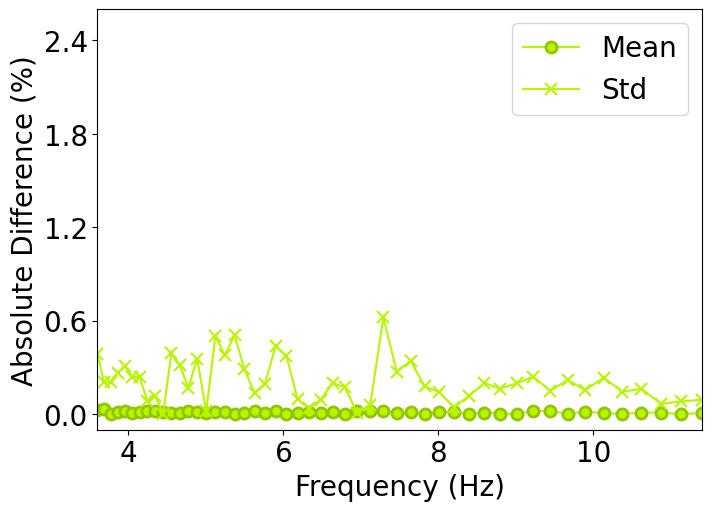

  (a/mu = 0.04012, sigma1^2 = 0.02796)


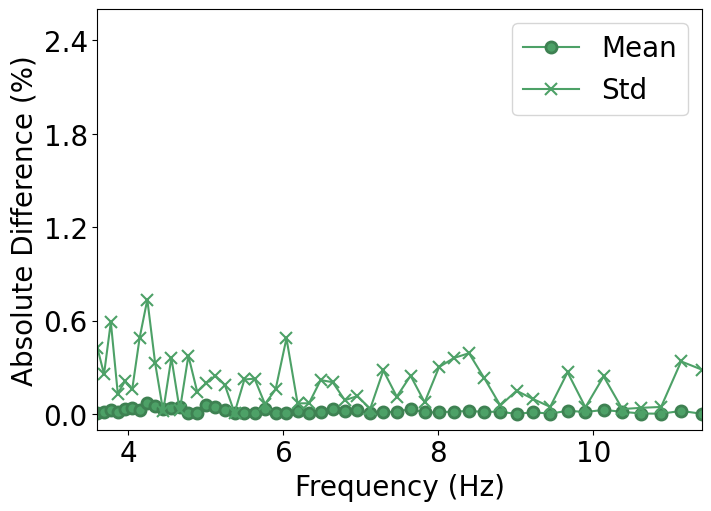

  (a/mu = 0.04043, sigma1^2 = 0.05048)
  (a/mu = 0.03862, sigma1^2 = 0.04395)
  (a/mu = 0.03723, sigma1^2 = 0.03897)


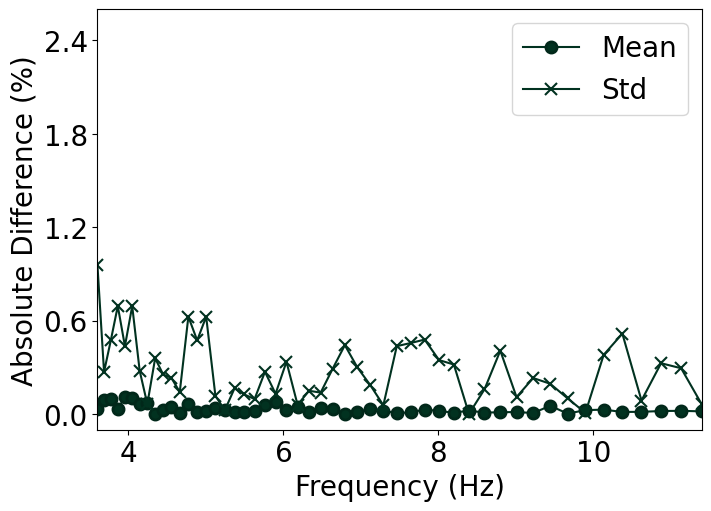

In [12]:
dist = 56.9  # distance in meters (as in your original code)
a_val = 0.045  # truncation parameter for the inverse moments computation

scale = np.sqrt(2)*0.9
noncentrality = dist
x = np.linspace(noncentrality-5, noncentrality+5, 1000)
# We ignore the returned PDF values; we only need mean and variance.
_, mean_rice, var_rice = pdf_rice(x, noncentrality, scale, l=1)

print("\nRice distribution (distance) moments:")
print("E[D] =", mean_rice, "[m]")
print("Var[D] =", var_rice, "[m]")

keys = ["w4", "w6", "w8"]  # your omega keys
nf = len(freq)  # number of frequencies

k=0
# Loop over each omega key and compute the moments for each frequency.
for w in keys:
    # Initialize arrays to hold the computed and sample moments for every frequency.
    computed_mean_time = np.zeros(nf)
    computed_var_time  = np.zeros(nf)
    sample_mean_time   = np.zeros(nf)
    sample_var_time    = np.zeros(nf)
    
    computed_mean_comb = np.zeros(nf)
    computed_var_comb  = np.zeros(nf)
    sample_mean_comb   = np.zeros(nf)
    sample_var_comb   = np.zeros(nf)
    
    for i in range(nf):
        # --- For time uncertainty data ---
        # These arrays are assumed to have shape (n_samples, n_freqs)
        # "lag_time_lagUncertain_heis" is used to compute the inverse moments
        # "lagUncertain_heis" gives the velocity samples computed from time uncertainty.
        lag_time = data_w[w]["lag_time_lagUncertain_heis"][:, i]
        vel_time = data_w[w]["lagUncertain_heis"][:, i]
        
        # Compute the mean and standard deviation of the lag time samples.
        mu_time    = data_w[w]["picked_lag_times"][i]
        sigma_time = data_w[w]["heisenberg_std"][i]
        # Compute inverse moments for Y = d/X (velocity) using the provided function.
        E_inv, var_inv = compute_inverse_moments(mu_time, sigma_time, a_val)

        computed_mean_time[i] = dist * E_inv
        computed_var_time[i]  = (dist**2) * var_inv
        
        # Compute the sample moments for the time-uncertainty-based velocity.
        sample_mean_time[i] = np.mean(vel_time)
        sample_var_time[i]  = np.var(vel_time)
        
        # --- For combined uncertainty data ---
        # "CombUncertain_heis" holds the velocity samples for combined uncertainty.
        vel_comb = data_w[w]["CombUncertain_heis"][:, i]
        sample_mean_comb[i] = np.mean(vel_comb)
        sample_var_comb[i]  = np.var(vel_comb)

        # Computed combined moments: product of Rice moments and inverse moments.
        # Product Mean = mean_rice * E_inv
        computed_mean_comb[i] = mean_rice * E_inv
        # Product Variance = (var_rice + mean_rice^2) * (var_inv + E_inv^2) - (mean_rice * E_inv)^2
        computed_var_comb[i] = (var_rice + mean_rice**2) * (var_inv + E_inv**2) - (mean_rice * E_inv)**2

    
    # Now create the four plots for this omega key:
    computed_std_time = np.sqrt(computed_var_time)
    sample_std_time = np.sqrt(sample_var_time)
    computed_std_comb = np.sqrt(computed_var_comb)
    sample_std_comb = np.sqrt(sample_var_comb)
    
    # 1. Mean of time uncertainty: computed vs. sample
    # plt.figure(figsize=(7,5))
    # plt.plot(freq, computed_mean_time, 'ro', label="Analytical Mean (Time)")
    # plt.plot(freq, sample_mean_time, 'bx', label="Sample Mean (Time)")
    # plt.xlabel("Frequency (Hz)")
    # plt.ylabel("Group Velocity (m/s)")
    # plt.title(f"{format_omega(w)}: Mean of Time Uncertainty Based Velocity")
    # plt.legend()
    # plt.grid(False)
    # plt.ylim(25,55)
    # plt.show()
    
    # # 2. Variance of time uncertainty: computed vs. sample
    # plt.figure(figsize=(7,5))
    # plt.plot(freq, computed_std_time, 'ro', label="Analytical std (Time)")
    # plt.plot(freq, sample_std_time, 'bx', label="Sample std (Time)")
    # plt.xlabel("Frequency (Hz)")
    # plt.ylabel("Variance ((m/s)^2)")
    # plt.title(f"{format_omega(w)}: Standard deviation of Time Uncertainty Based Velocity")
    # plt.legend()
    # plt.grid(False)
    # plt.ylim((0,10))
    # plt.show()
    
    # 3. Mean of combined uncertainty 
    # plt.figure(figsize=(7,5))
    # plt.plot(freq, computed_mean_comb, 'ro', label="Analytical Mean (Combined)")
    # plt.plot(freq, sample_mean_comb, 'bx', label="Sample Mean (Combined)")
    # plt.xlabel("Frequency (Hz)")
    # plt.ylabel("Group Velocity (m/s)")
    # plt.title(f"{format_omega(w)}: Mean of Combined Uncertainty Based Velocity")
    # plt.legend()
    # plt.grid(False)
    # plt.ylim(25,55)
    # plt.show()
    
    # # 4. Variance of combined uncertainty (sample only)
    # plt.figure(figsize=(7,5))
    # plt.plot(freq, computed_std_comb, 'ro', label="Analytical std (Combined)")
    # plt.plot(freq, sample_std_comb, 'bx', label="Sample std (Combined)")
    # plt.xlabel("Frequency (Hz)")
    # plt.ylabel("Variance ((m/s)^2)")
    # plt.title(f"{format_omega(w)}: Standard deviation of Combined Uncertainty Based Velocity")
    # plt.ylim((0,10))
    # plt.grid(False)
    # plt.legend()
    # plt.show()


    # --- Compute Percentage Differences ---
    # Percentage difference = 100 * (Sample - Computed) / Computed
    pct_diff_mean_time = 100 * (sample_mean_time - computed_mean_time) / computed_mean_time
    pct_diff_std_time  = 100 * (computed_std_time  - sample_std_time)  / computed_std_time

    pct_diff_mean_comb = 100 * (sample_mean_comb - computed_mean_comb) / computed_mean_comb
    pct_diff_std_comb  = 100 * (sample_std_comb  - computed_std_comb)  / computed_std_comb

    # --- Final Plots for Time Uncertainty ---
    # plt.figure(figsize=(7,5))
    # plt.plot(freq, pct_diff_mean_time, 'bo-', label="Mean % Difference (Time)")
    # plt.plot(freq, pct_diff_std_time, 'ro-', label="Std % Difference (Time)")
    # plt.xlabel("Frequency (Hz)")
    # plt.ylabel("% Difference")
    # plt.title(f"{format_omega(w)}: % Differences for Time Uncertainty Moments")
    # plt.legend()
    # plt.ylim((-1.5,1.5))
    # plt.show()

    colors = ['#B8F500', '#4DA167', '#013220']
    color_p = colors[k]
    # Helper to return a darker shade of any Matplotlib color:
    def darken(color, amount=0.7):
        """
        Make color darker by scaling its RGB components.
        amount < 1 => darker; amount > 1 => lighter.
        """
        c = np.array(mcolors.to_rgb(color))
        c_darker = np.clip(c * amount, 0, 1)
        return tuple(c_darker)

    edge_color = darken(color_p, amount=0.8)

    plt.rcParams.update({'font.size': 20})
    # --- Final Plots for Combined Uncertainty ---
    plt.figure(figsize=(7, 5), constrained_layout=True)
    plt.plot(
        freq,
        np.abs(pct_diff_mean_comb),
        marker='o',
        linestyle='-',
        color=color_p,                  # line color
        markerfacecolor=color_p,        # fill of the circles
        markeredgecolor=edge_color,     # darker ring
        markeredgewidth=2,              # thickness of the ring
        markersize=8,                   # size of the circles
        label="Mean"
    )
    plt.plot(freq, np.abs(pct_diff_std_comb), 'x-', markersize = 9, markeredgewidth = 1.5, color = color_p, label="Std")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Absolute Difference (%)")
    #plt.title(f"{format_omega(w)}: % Differences for Combined Uncertainty Moments")
    plt.legend()
    plt.xlim(3.6,11.4)
    plt.ylim(-0.1, 2.6)
    # plt.ylim(5e-5, 10)
    ax = plt.gca()
    # ax.set_yscale('log')
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    plt.show()
    k=k+1